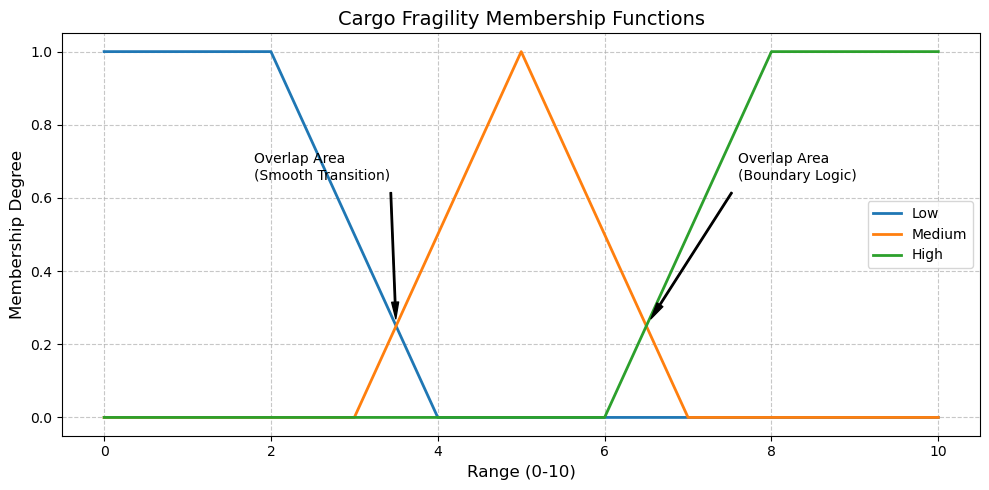

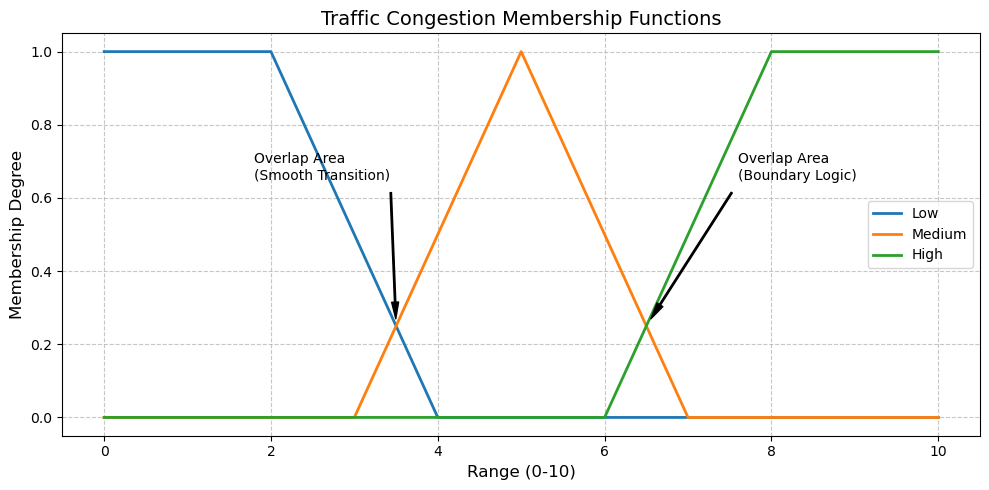

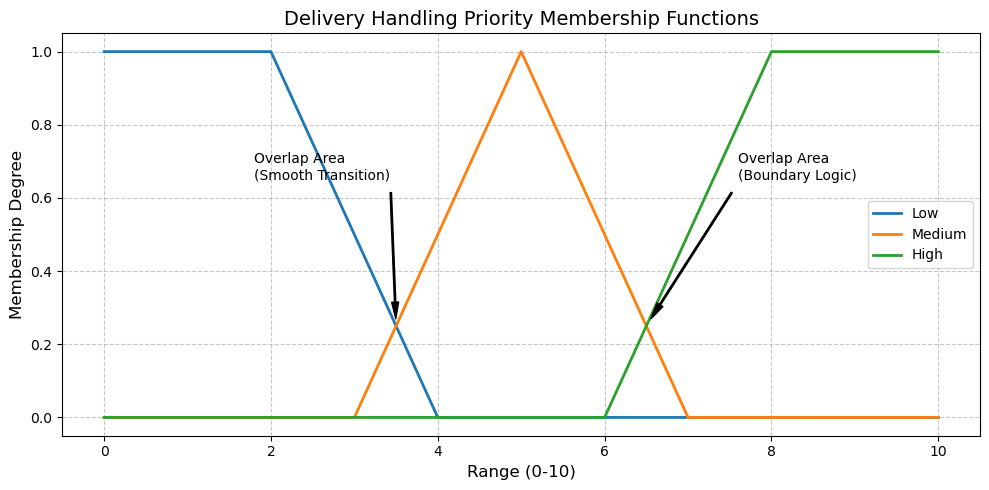

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# create a range from 0 to 10 (step = 0.1)
x = np.arange(0, 10.1, 0.1)

# triangular membership function
# used for the "Medium" category
def trimf(x, abc):
    a, b, c = abc
    y = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        if a < xi < b:
            y[i] = (xi - a) / (b - a)
        elif xi == b:
            y[i] = 1.0
        elif b < xi < c:
            y[i] = (c - xi) / (c - b)
    return y

# trapezoidal membership function
# used for "Low" and "High" categories
def trapmf(x, abcd):
    a, b, c, d = abcd
    y = np.zeros_like(x, dtype=float)
    for i, xi in enumerate(x):
        if a < xi < b:
            y[i] = (xi - a) / (b - a)
        elif b <= xi <= c:
            y[i] = 1.0
        elif c < xi < d:
            y[i] = (d - xi) / (d - c)
    return y

# membership functions based on the values used in the report
low = trapmf(x, [0, 0, 2, 4])
medium = trimf(x, [3, 5, 7])
high = trapmf(x, [6, 8, 10, 10])

# function to plot and save the membership graph
def plot_membership(title, filename):
    plt.figure(figsize=(10, 5))

    # plot each fuzzy set
    plt.plot(x, low, linewidth=2, label='Low')
    plt.plot(x, medium, linewidth=2, label='Medium')
    plt.plot(x, high, linewidth=2, label='High')

    # basic formatting for readability
    plt.title(title, fontsize=14)
    plt.xlabel('Range (0-10)', fontsize=12)
    plt.ylabel('Membership Degree', fontsize=12)
    plt.legend(loc='center right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # highlight overlap between Low and Medium
    plt.annotate(
        'Overlap Area\n(Smooth Transition)',
        xy=(3.5, 0.25),
        xytext=(1.8, 0.65),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
        fontsize=10
    )

    # highlight overlap between Medium and High
    plt.annotate(
        'Overlap Area\n(Boundary Logic)',
        xy=(6.5, 0.25),
        xytext=(7.6, 0.65),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
        fontsize=10
    )

    # adjust layout and save image
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# generate three graphs for the report
plot_membership(
    'Cargo Fragility Membership Functions',
    'figure1_fragility.png'
)

plot_membership(
    'Traffic Congestion Membership Functions',
    'figure2_congestion.png'
)

plot_membership(
    'Delivery Handling Priority Membership Functions',
    'figure3_priority.png'
)